## 1. Setup

In [1]:
!pip install -q wfdb PyWavelets

import os, glob, time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt, iirnotch, kaiserord, firwin
import pywt
import wfdb
from wfdb import processing

plt.rcParams['figure.dpi'] = 110


## 2. Data Loading

In [2]:
candidates = glob.glob('/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/**/*.dat', recursive=True)
print(f"Found {len(candidates)} .dat files")
print(candidates[:5])

DATA_DIR = os.path.dirname(candidates[0])
print("\nUsing DATA_DIR =", DATA_DIR)
print(sorted(os.listdir(DATA_DIR))[:15])


Found 71 .dat files
['/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/103.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/113.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/202.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/217.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/219.dat']

Using DATA_DIR = /kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0
['100.atr', '100.dat', '100.hea', '100.xws', '101.atr', '101.dat', '101.hea', '101.xws', '102-0.atr', '102.atr', '102.dat', '102.hea', '102.xws', '103.atr', '103.dat']


In [3]:
records = sorted(set(os.path.basename(f).replace('.dat', '') for f in glob.glob(f'{DATA_DIR}/*.dat')))
print(f"Total records: {len(records)}")
print(records)


Total records: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [4]:
sample_rec = wfdb.rdrecord(os.path.join(DATA_DIR, records[0]))

print("Record name        :", sample_rec.record_name)
print("Sampling frequency  :", sample_rec.fs, "Hz")
print("Signal length       :", sample_rec.sig_len, "samples =", sample_rec.sig_len / sample_rec.fs, "s")
print("Number of leads     :", sample_rec.n_sig)
print("Lead names          :", sample_rec.sig_name)
print("Units               :", sample_rec.units)
print("ADC gain            :", sample_rec.adc_gain)
print("Comments            :", sample_rec.comments)


Record name        : 100
Sampling frequency  : 360 Hz
Signal length       : 650000 samples = 1805.5555555555557 s
Number of leads     : 2
Lead names          : ['MLII', 'V5']
Units               : ['mV', 'mV']
ADC gain            : [200.0, 200.0]
Comments            : ['69 M 1085 1629 x1', 'Aldomet, Inderal']


In [5]:
all_symbols = Counter()
for rec_name in records:
    try:
        ann = wfdb.rdann(os.path.join(DATA_DIR, rec_name), 'atr')
        all_symbols.update(ann.symbol)
    except Exception as e:
        print(f"Skipped {rec_name}: {e}")

print("Beat symbol counts across all 48 records:")
for sym, count in all_symbols.most_common(15):
    print(f"  {sym!r:>4}: {count}")


Beat symbol counts across all 48 records:
   'N': 75052
   'L': 8075
   'R': 7259
   'V': 7130
   '/': 7028
   'A': 2546
   '+': 1291
   'f': 982
   'F': 803
   '~': 616
   '!': 472
   '"': 437
   'j': 229
   'x': 193
   'a': 150


## 3. Noise Profiling

Identify which record is dominated by baseline wander (worst case for
denoising) and which is cleanest, so all filter comparisons below are done
on a representative "hard" case.

In [6]:
def band_power_fraction(x, lo, hi, fs):
    f, p = signal.welch(x, fs=fs, nperseg=2048)
    total = np.trapezoid(p, f)
    m = (f >= lo) & (f <= hi)
    return 100 * np.trapezoid(p[m], f[m]) / total if total > 0 else 0

noise_profile = []
for rec_name in records:
    rec = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    x = rec.p_signal[:, 0]   # MLII lead
    fs = rec.fs
    bw = band_power_fraction(x, 0, 0.5, fs)
    pl = band_power_fraction(x, 59, 61, fs)
    hf = band_power_fraction(x, 100, fs / 2, fs)
    noise_profile.append((rec_name, bw, pl, hf))

noise_profile.sort(key=lambda r: -r[1])
print(f"{'Record':<8}{'BaselineWander%':>16}{'Powerline%':>12}{'HighFreq%':>12}")
for r in noise_profile:
    print(f"{r[0]:<8}{r[1]:>16.2f}{r[2]:>12.3f}{r[3]:>12.4f}")


Record   BaselineWander%  Powerline%   HighFreq%
108                39.78       0.088      0.0235
121                28.05       0.002      0.0257
111                22.48       0.180      0.0297
222                21.15       0.288      0.0547
219                18.35       0.002      0.0051
114                17.37       0.459      0.0774
203                14.38       0.057      0.0095
228                14.26       0.056      0.0165
207                13.69       0.058      0.0130
116                13.69       0.004      0.0110
112                12.22       0.007      0.0304
124                12.09       0.001      0.0071
101                10.99       0.081      0.0208
234                10.23       0.003      0.0127
115                 9.64       0.002      0.0182
209                 9.49       0.104      0.0250
105                 8.46       0.033      0.0086
208                 7.56       0.054      0.0076
212                 7.50       0.114      0.0171
210                 

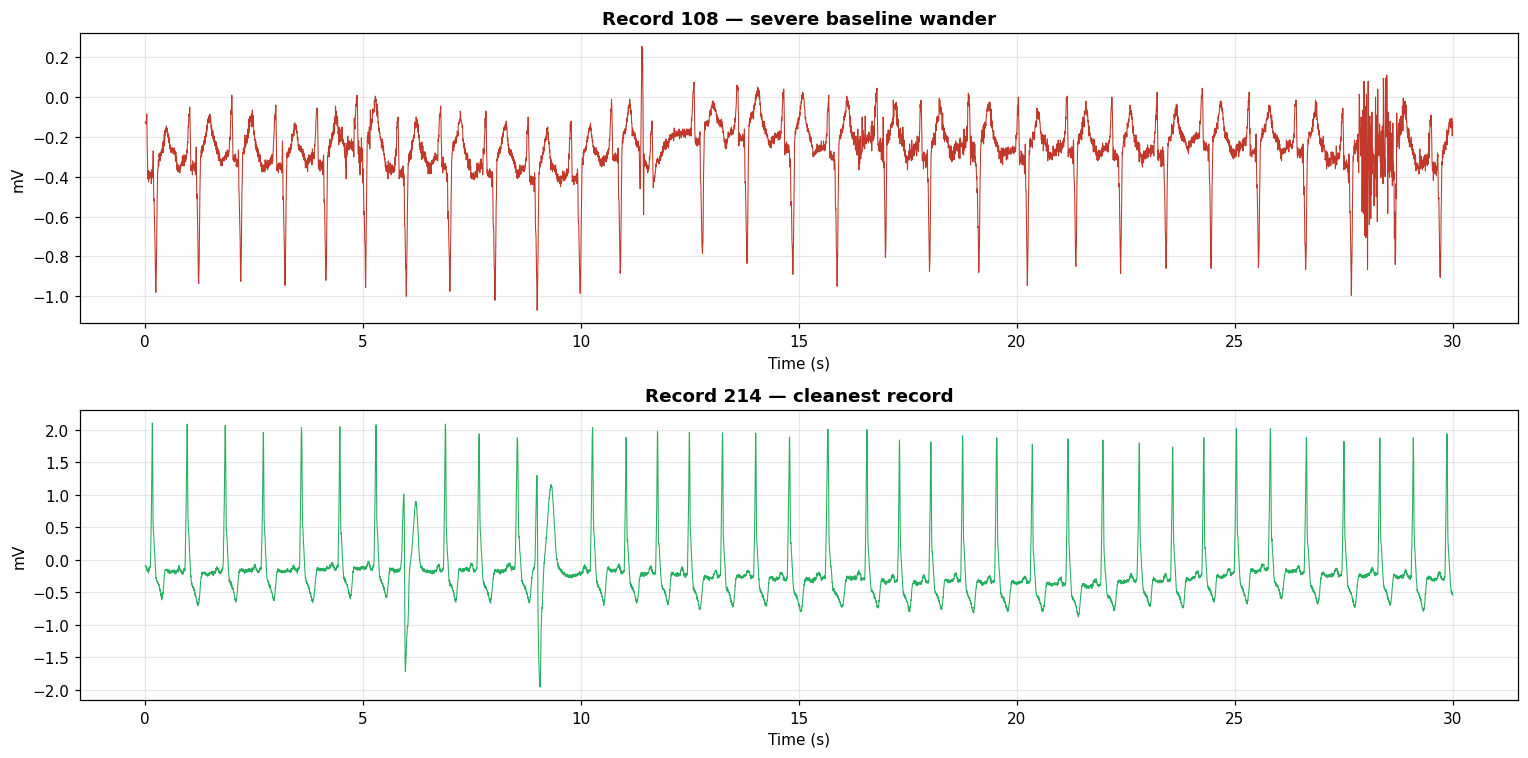

In [7]:
# Record 108 = worst baseline wander -> good demo/stress-test case
# Record 214 = cleanest -> contrast case
WORST_BW = '108'
CLEANEST = '214'

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, rec_name, title in [(axes[0], WORST_BW, f'Record {WORST_BW} — severe baseline wander'),
                             (axes[1], CLEANEST, f'Record {CLEANEST} — cleanest record')]:
    rec = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    x = rec.p_signal[:int(rec.fs * 30), 0]
    t = np.arange(len(x)) / rec.fs
    ax.plot(t, x, linewidth=0.7, color='#c0392b' if rec_name == WORST_BW else '#27ae60')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('mV'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


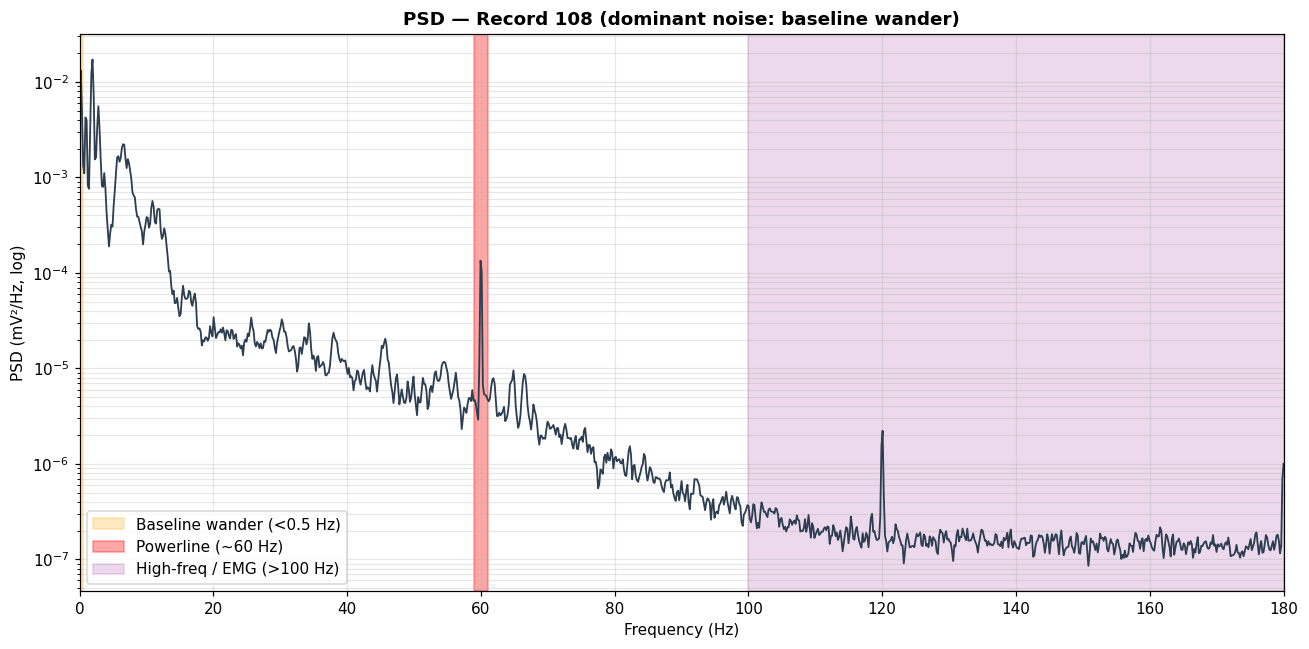

In [8]:
# Full working signal for the rest of Section 3-5: record 108, first 2 minutes
RECORD = WORST_BW
rec = wfdb.rdrecord(os.path.join(DATA_DIR, RECORD))
FS = rec.fs
x = rec.p_signal[:FS * 120, 0]
fs = FS
t = np.arange(len(x)) / fs

freqs, psd = signal.welch(x, fs=fs, nperseg=2048)
fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(freqs, psd, color='#2c3e50', linewidth=1.2)
ax.axvspan(0, 0.5, color='orange', alpha=0.25, label='Baseline wander (<0.5 Hz)')
ax.axvspan(59, 61, color='red', alpha=0.35, label='Powerline (~60 Hz)')
ax.axvspan(100, fs / 2, color='purple', alpha=0.15, label='High-freq / EMG (>100 Hz)')
ax.set_xlim(0, 180)
ax.set_title(f'PSD — Record {RECORD} (dominant noise: baseline wander)', fontweight='bold')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (mV²/Hz, log)')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## 4. Classical Filtering (Butterworth / Notch / FIR-Kaiser)

In [9]:
def highpass(x, cutoff=0.5, fs=FS, order=4):
    b, a = butter(order, cutoff / (fs / 2), btype='high')
    return filtfilt(b, a, x)

def lowpass(x, cutoff=35, fs=FS, order=4):
    b, a = butter(order, cutoff / (fs / 2), btype='low')
    return filtfilt(b, a, x)

def bandpass(x, low=0.5, high=35, fs=FS, order=4):
    b, a = butter(order, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, x)

def notch60(x, f0=60, Q=30, fs=FS):
    b, a = iirnotch(f0 / (fs / 2), Q)
    return filtfilt(b, a, x)

def fir_bandstop_kaiser(x, f0=60, notch_width=4, ripple_db=60, trans_width=2, fs=FS):
    nyq = fs / 2
    N, beta = kaiserord(ripple_db, trans_width / nyq)
    if N % 2 == 0:
        N += 1
    taps = firwin(N, [(f0 - notch_width / 2) / nyq, (f0 + notch_width / 2) / nyq],
                   window=('kaiser', beta), pass_zero='bandstop')
    return filtfilt(taps, [1.0], x)

def plot_fft(x, fs, title, ax):
    n = len(x)
    freqs = np.fft.rfftfreq(n, 1 / fs)
    mag = np.abs(np.fft.rfft(x)) / n
    ax.plot(freqs, mag, linewidth=0.8)
    ax.set_xlim(0, 100)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Hz'); ax.set_ylabel('|X(f)|')
    ax.axvline(60, color='r', linestyle='--', alpha=0.5, label='60Hz')
    ax.legend()


In [10]:
# variants dict is built up incrementally as each method is introduced,
# and reused everywhere below (Sections 4-6) -- nothing here gets recomputed twice.
variants = {
    'raw':                 x,
    'highpass_only':       highpass(x),
    'bandpass_only':       bandpass(x),
    'bandpass+notch':      notch60(bandpass(x)),
    'bandpass+fir_kaiser': fir_bandstop_kaiser(bandpass(x)),
}

print(f"{'Variant':<20}{'BaselineWander%':>16}{'Powerline%':>12}{'HighFreq%':>12}")
for name, sig in variants.items():
    bw = band_power_fraction(sig, 0, 0.5, fs)
    pl = band_power_fraction(sig, 59, 61, fs)
    hf = band_power_fraction(sig, 100, fs / 2, fs)
    print(f"{name:<20}{bw:>16.3f}{pl:>12.4f}{hf:>12.4f}")


Variant              BaselineWander%  Powerline%   HighFreq%
raw                           12.450      0.2148      0.0610
highpass_only                  0.048      0.2534      0.0720
bandpass_only                  0.051      0.0000      0.0000
bandpass+notch                 0.051      0.0000      0.0000
bandpass+fir_kaiser            0.051      0.0000      0.0000


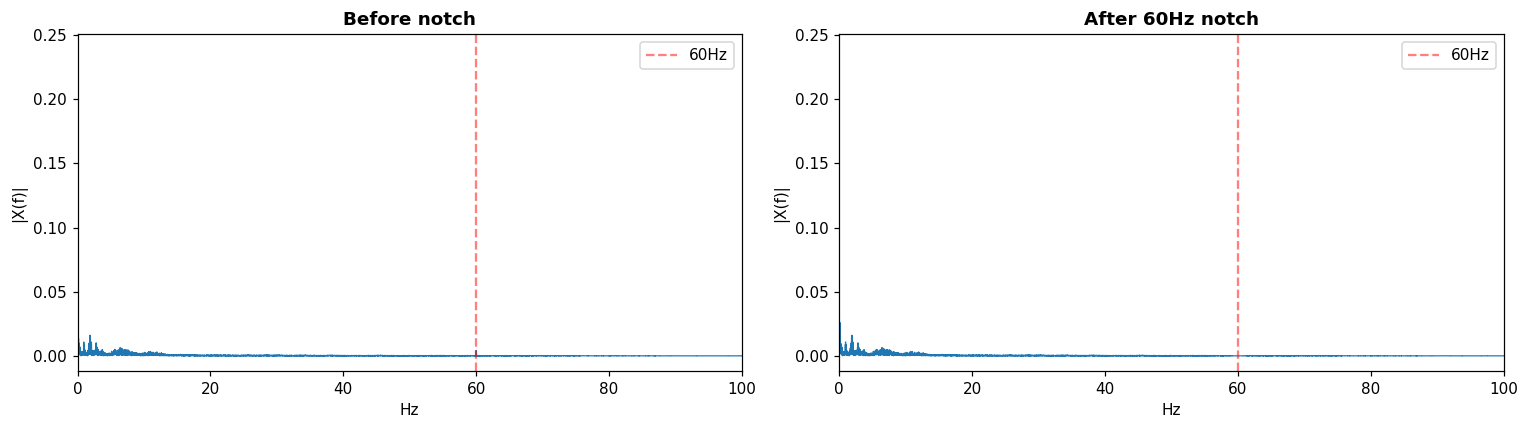

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_fft(x, fs, 'Before notch', axes[0])
plot_fft(notch60(x), fs, 'After 60Hz notch', axes[1])
plt.tight_layout(); plt.show()


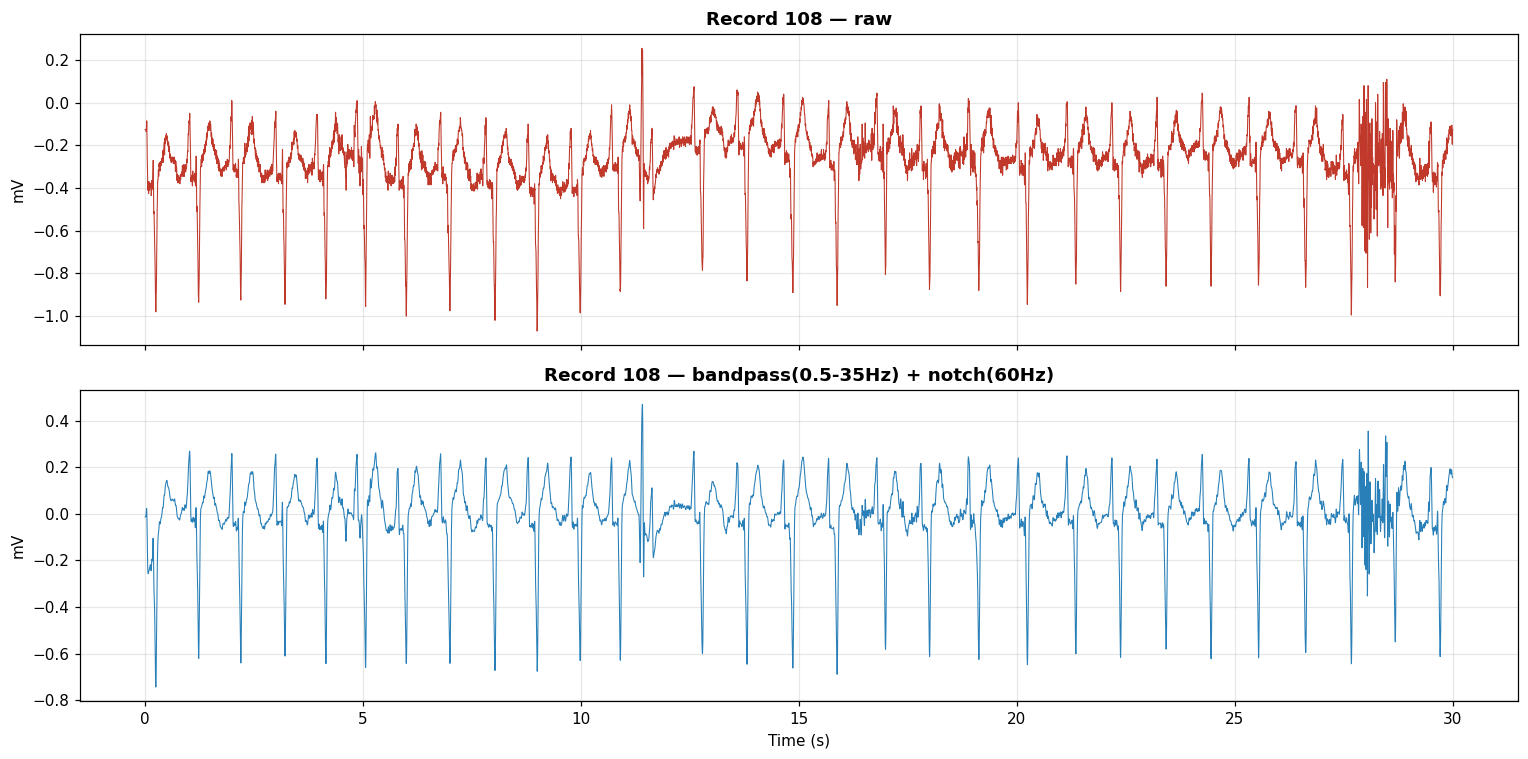

In [12]:
best_classical = variants['bandpass+notch']
t30 = np.arange(int(fs * 30)) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(t30, x[:int(fs * 30)], linewidth=0.7, color='#c0392b')
axes[0].set_title(f'Record {WORST_BW} — raw', fontweight='bold')
axes[1].plot(t30, best_classical[:int(fs * 30)], linewidth=0.7, color='#2980b9')
axes[1].set_title(f'Record {WORST_BW} — bandpass(0.5-35Hz) + notch(60Hz)', fontweight='bold')
for ax in axes:
    ax.set_ylabel('mV'); ax.grid(alpha=0.3)
axes[1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()


## 5. Wavelet Denoising (SWT & DWT)

In [13]:
def swt_denoise(x, wavelet='rbio3.9', level=5, threshold_scale=0.5):
    n = len(x)
    pad = (2 ** level - n % 2 ** level) % 2 ** level
    x_pad = np.pad(x, (0, pad), mode='reflect')
    coeffs = pywt.swt(x_pad, wavelet, level=level)
    denoised_coeffs = []
    for i, (cA, cD) in enumerate(coeffs):
        sigma = np.median(np.abs(cD)) / 0.6745
        thresh = threshold_scale * sigma * np.sqrt(2 * np.log(len(cD)))
        cD_thresh = pywt.threshold(cD, thresh, mode='soft')
        if i == len(coeffs) - 1:          # last level = baseline component
            cA = cA - np.median(cA)
        denoised_coeffs.append((cA, cD_thresh))
    rec = pywt.iswt(denoised_coeffs, wavelet)
    return rec[:n]

def dwt_denoise(x, wavelet='rbio3.9', level=5, threshold_scale=0.5):
    coeffs = pywt.wavedec(x, wavelet, level=level)
    cA = coeffs[0] - np.median(coeffs[0])
    denoised = [cA]
    for cD in coeffs[1:]:
        sigma = np.median(np.abs(cD)) / 0.6745
        thresh = threshold_scale * sigma * np.sqrt(2 * np.log(len(cD)))
        denoised.append(pywt.threshold(cD, thresh, mode='soft'))
    rec = pywt.waverec(denoised, wavelet)
    return rec[:len(x)]

# Compute both wavelet variants ONCE and register them in `variants`
# (previously 'dwt_rbio3.9' was read later but never actually added here -> KeyError)
swt_sig = swt_denoise(x)
dwt_sig = dwt_denoise(x)
variants['swt_rbio3.9'] = swt_sig
variants['dwt_rbio3.9'] = dwt_sig

print(f"{'Variant':<20}{'BaselineWander%':>16}{'Powerline%':>12}{'HighFreq%':>12}")
for name, sig in variants.items():
    bw = band_power_fraction(sig, 0, 0.5, fs)
    pl = band_power_fraction(sig, 59, 61, fs)
    hf = band_power_fraction(sig, 100, fs / 2, fs)
    print(f"{name:<20}{bw:>16.3f}{pl:>12.4f}{hf:>12.4f}")


Variant              BaselineWander%  Powerline%   HighFreq%
raw                           12.450      0.2148      0.0610
highpass_only                  0.048      0.2534      0.0720
bandpass_only                  0.051      0.0000      0.0000
bandpass+notch                 0.051      0.0000      0.0000
bandpass+fir_kaiser            0.051      0.0000      0.0000
swt_rbio3.9                   15.446      0.0111      0.0034
dwt_rbio3.9                   14.645      0.0162      0.0091


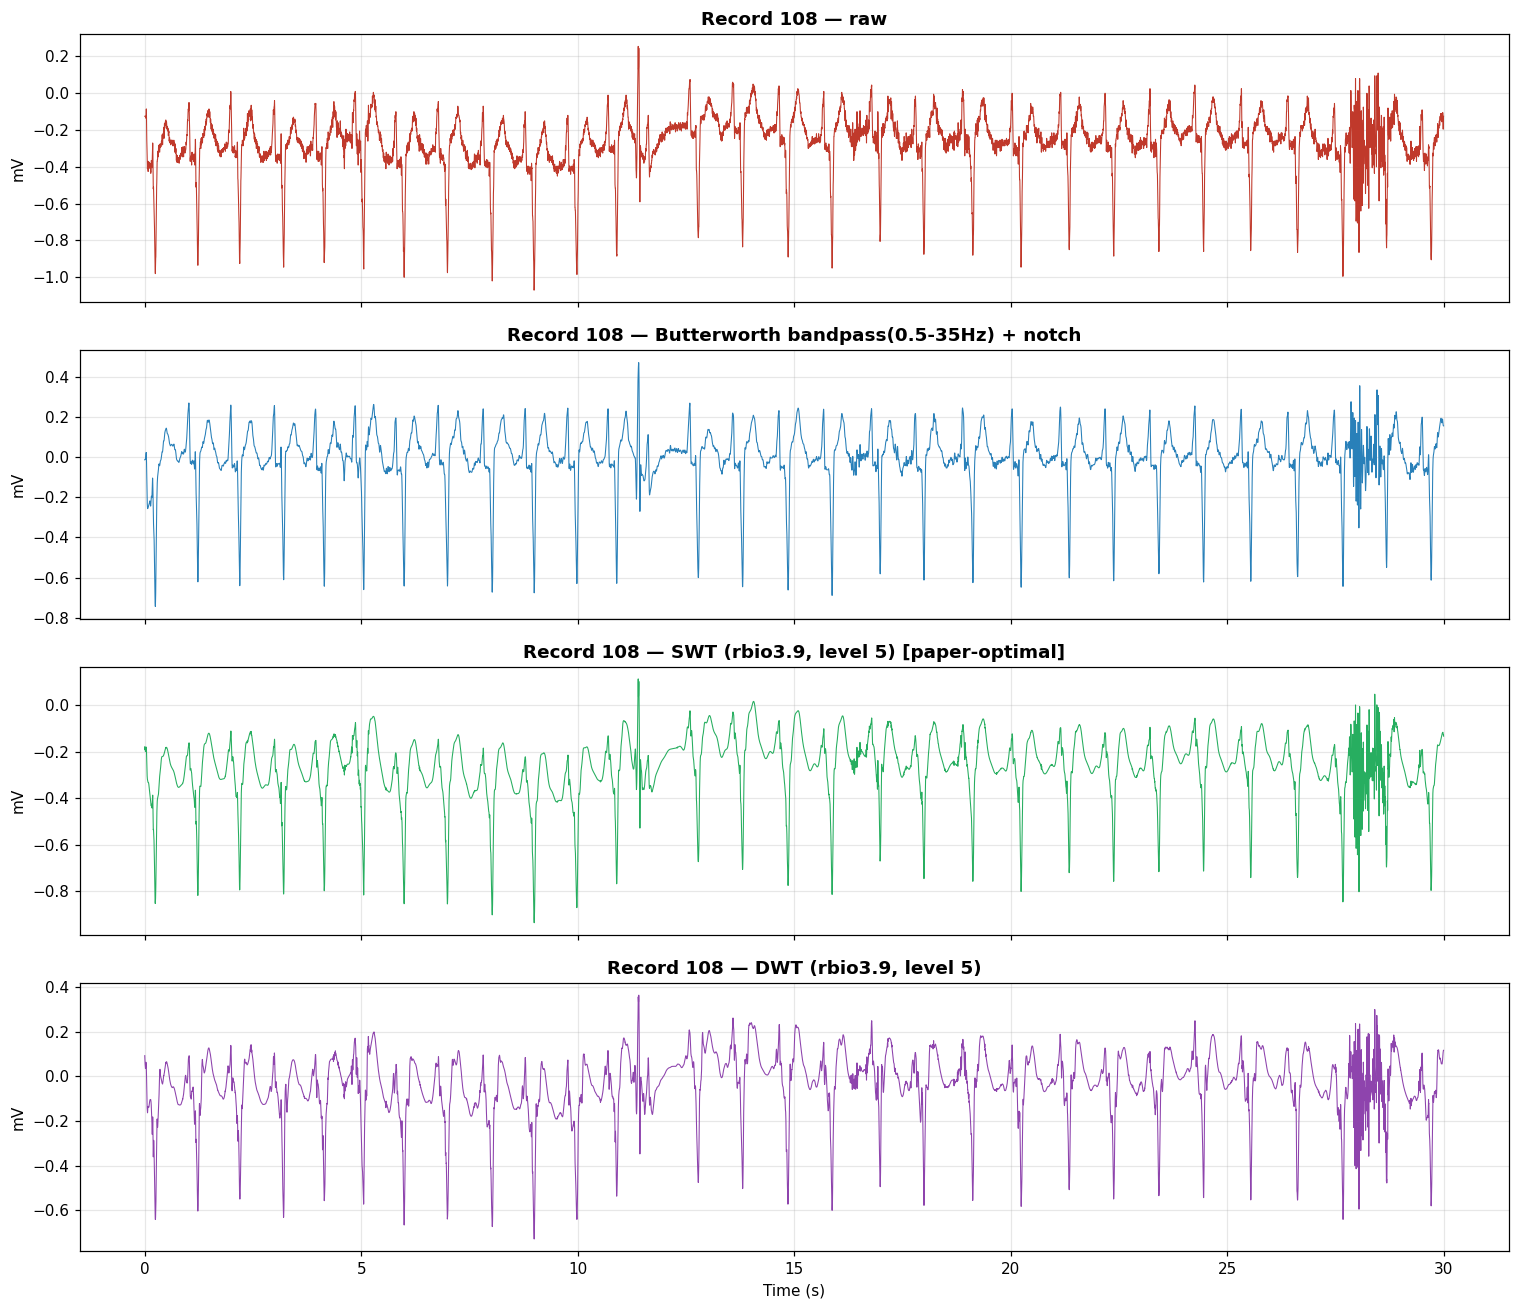

In [14]:
# 4-panel comparison: raw vs. best classical filter vs. SWT vs. DWT
# (dwt_sig is now defined *before* this plot -- fixes the previous NameError)
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t30, x[:int(fs * 30)], linewidth=0.7, color='#c0392b')
axes[0].set_title(f'Record {WORST_BW} — raw', fontweight='bold')

axes[1].plot(t30, variants['bandpass+notch'][:int(fs * 30)], linewidth=0.7, color='#2980b9')
axes[1].set_title(f'Record {WORST_BW} — Butterworth bandpass(0.5-35Hz) + notch', fontweight='bold')

axes[2].plot(t30, swt_sig[:int(fs * 30)], linewidth=0.7, color='#27ae60')
axes[2].set_title(f'Record {WORST_BW} — SWT (rbio3.9, level 5) [paper-optimal]', fontweight='bold')

axes[3].plot(t30, dwt_sig[:int(fs * 30)], linewidth=0.7, color='#8e44ad')
axes[3].set_title(f'Record {WORST_BW} — DWT (rbio3.9, level 5)', fontweight='bold')

for ax in axes:
    ax.set_ylabel('mV'); ax.grid(alpha=0.3)
axes[3].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()


## 6. Quantitative Comparison — SNR & Correlation

In [15]:
def snr_improvement(raw, filtered):
    noise = raw - filtered
    signal_power = np.sum(filtered ** 2)
    noise_power = np.sum(noise ** 2)
    return 10 * np.log10(signal_power / noise_power) if noise_power > 0 else np.inf

print(f"{'Variant':<20}{'SNR (dB)':>10}{'Corr-with-raw':>16}")
for name in ['bandpass+notch', 'swt_rbio3.9', 'dwt_rbio3.9']:
    snr = snr_improvement(x, variants[name])
    corr = np.corrcoef(x, variants[name])[0, 1]
    print(f"{name:<20}{snr:>10.2f}{corr:>16.4f}")


Variant               SNR (dB)   Corr-with-raw
bandpass+notch           -5.20          0.8397
swt_rbio3.9              16.64          0.9699
dwt_rbio3.9              -3.50          0.9646


In [16]:
# Robustness check: does SWT stay the best choice across other records too,
# not just the worst-case one (108)?
print(f"{'Record':<8}{'Technique':<20}{'SNR(dB)':>10}{'Corr':>8}")
for rec_name in ['108', '121', '111', '222']:
    rec_r = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    xr = rec_r.p_signal[:, 0]
    v = {
        'bandpass+notch': notch60(bandpass(xr)),
        'swt_rbio3.9':    swt_denoise(xr),
        'dwt_rbio3.9':    dwt_denoise(xr),
    }
    for name, sig in v.items():
        snr = snr_improvement(xr, sig)
        corr = np.corrcoef(xr, sig)[0, 1]
        print(f"{rec_name:<8}{name:<20}{snr:>10.2f}{corr:>8.4f}")


Record  Technique              SNR(dB)    Corr
108     bandpass+notch           -5.68  0.5927
108     swt_rbio3.9              18.55  0.9900
108     dwt_rbio3.9               1.93  0.9856
121     bandpass+notch          -13.63  0.5926
121     swt_rbio3.9              28.79  0.9948
121     dwt_rbio3.9              -8.88  0.9914
111     bandpass+notch           -1.94  0.7479
111     swt_rbio3.9              13.49  0.9728
111     dwt_rbio3.9               2.25  0.9580
222     bandpass+notch           -3.87  0.7510
222     swt_rbio3.9              14.58  0.9739
222     dwt_rbio3.9               0.83  0.9642


## 7. Batch Preprocessing — Apply the Chosen Method (SWT) to All Records

SWT (rbio3.9, level 5) wins on SNR, correlation, and (Section 9 below) morphology
preservation, so it's applied once to the full 48-record set here. Everything
downstream (R-peak detection, morphology analysis) reuses this single `cleaned`
dict — it is **not** recomputed anywhere else in the notebook.

In [17]:
def preprocess_record(rec_name, data_dir=DATA_DIR):
    rec = wfdb.rdrecord(os.path.join(data_dir, rec_name))
    x_r = rec.p_signal[:, 0]
    return swt_denoise(x_r), rec.fs

cleaned = {}
fs_by_record = {}
t0 = time.time()
for rec_name in records:
    sig, fs_r = preprocess_record(rec_name)
    cleaned[rec_name] = sig
    fs_by_record[rec_name] = fs_r
print(f"Preprocessed {len(cleaned)} records in {time.time() - t0:.1f}s")


Preprocessed 48 records in 15.6s


## 8. R-Peak Detection

In [18]:
def detect_rpeaks(sig, fs):
    xqrs = processing.XQRS(sig=sig, fs=fs)
    xqrs.detect(verbose=False)
    return xqrs.qrs_inds

fs_108 = fs_by_record['108']
r_peaks = detect_rpeaks(cleaned['108'], fs_108)
print(f"Detected {len(r_peaks)} R-peaks in record 108")


Detected 1767 R-peaks in record 108


In [19]:
def evaluate_detection(rec_name, cleaned_sig, fs, tol_ms=100):
    ann = wfdb.rdann(os.path.join(DATA_DIR, rec_name), 'atr')
    true_peaks = ann.sample[np.isin(ann.symbol, list('NLRBAaJSVrFejnE/fQ?'))]  # beat annotations only
    detected = detect_rpeaks(cleaned_sig, fs)

    tol = int(tol_ms / 1000 * fs)
    matched = 0
    used = np.zeros(len(detected), dtype=bool)
    for tp in true_peaks:
        diffs = np.abs(detected - tp)
        idx = np.argmin(diffs)
        if diffs[idx] <= tol and not used[idx]:
            matched += 1
            used[idx] = True

    sensitivity = matched / len(true_peaks) if len(true_peaks) else 0
    precision = matched / len(detected) if len(detected) else 0
    return len(true_peaks), len(detected), matched, sensitivity, precision

print(f"{'Record':<8}{'True':>6}{'Detected':>10}{'Matched':>9}{'Sens':>8}{'Prec':>8}")
for rec_name in ['108', '121', '111', '222', '100']:
    n_true, n_det, n_match, sens, prec = evaluate_detection(rec_name, cleaned[rec_name], fs_by_record[rec_name])
    print(f"{rec_name:<8}{n_true:>6}{n_det:>10}{n_match:>9}{sens:>8.3f}{prec:>8.3f}")


Record    True  Detected  Matched    Sens    Prec
108       1763      1767     1733   0.983   0.981
121       1863      1862     1861   0.999   0.999
111       2124      2122     2122   0.999   1.000
222       2483      2470     2469   0.994   1.000
100       2273      2273     2273   1.000   1.000


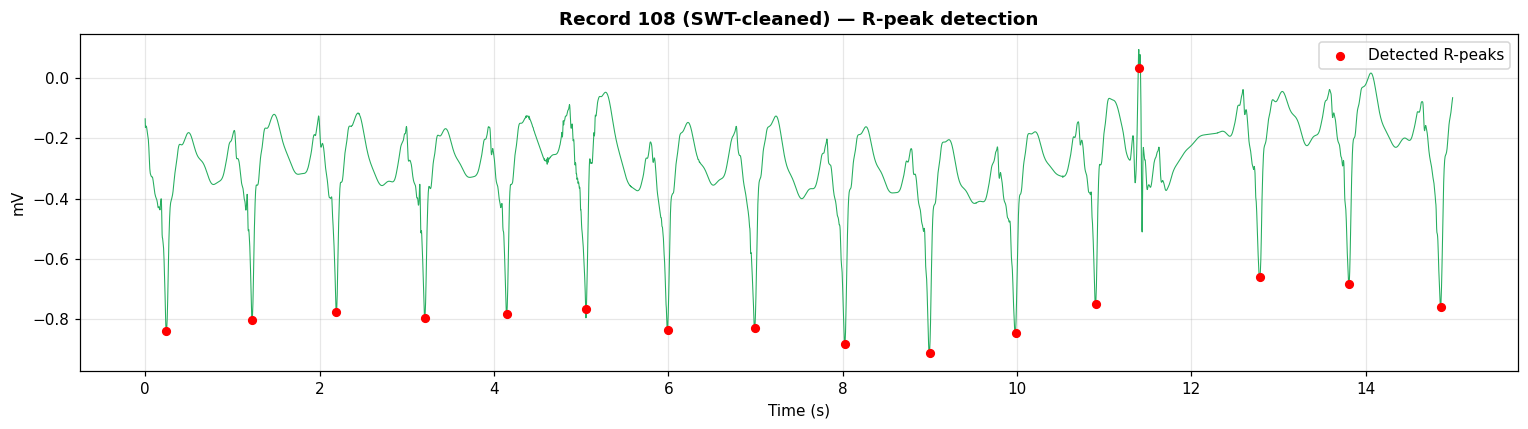

In [20]:
fig, ax = plt.subplots(figsize=(14, 4))
window = int(fs_108 * 15)
ax.plot(np.arange(window) / fs_108, cleaned['108'][:window], linewidth=0.7, color='#27ae60')
peaks_in_window = r_peaks[r_peaks < window]
ax.scatter(peaks_in_window / fs_108, cleaned['108'][peaks_in_window], color='red', s=25, zorder=5, label='Detected R-peaks')
ax.set_title('Record 108 (SWT-cleaned) — R-peak detection', fontweight='bold')
ax.set_xlabel('Time (s)'); ax.set_ylabel('mV'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Beat Morphology Analysis

Does denoising distort the diagnostically-important beat morphology (P/QRS/ST/T)? Built and used once, then reused for both the summary table and the overlay plot below.

In [21]:
def extract_morphology(sig, r_peaks_in, fs):
    windows = {
        'P_wave':     (-0.20, -0.10),
        'QRS':        (-0.05,  0.05),
        'ST_segment': ( 0.06,  0.12),
        'T_wave':     ( 0.15,  0.35),
    }
    results = {k: [] for k in windows}
    r_amp = []

    for r in r_peaks_in:
        if r - int(0.3 * fs) < 0 or r + int(0.4 * fs) >= len(sig):
            continue
        local = sig[r - int(0.05 * fs): r + int(0.05 * fs)]
        r_amp.append(np.max(local) - np.min(local))

        for name, (start, end) in windows.items():
            i0 = r + int(start * fs)
            i1 = r + int(end * fs)
            seg = sig[i0:i1]
            results[name].append(np.ptp(seg))

    summary = {k: (np.mean(v), np.std(v)) for k, v in results.items()}
    summary['R_amplitude'] = (np.mean(r_amp), np.std(r_amp))
    return summary


In [22]:
# Build the raw/filtered variants for record 108 ONCE; reused by the table
# below AND the single-beat overlay plot (previously rebuilt twice).
rec108 = wfdb.rdrecord(os.path.join(DATA_DIR, '108'))
x_raw_108 = rec108.p_signal[:, 0]
fs_r108 = rec108.fs

morph_variants = {
    'raw':             x_raw_108,
    'bandpass+notch':  notch60(bandpass(x_raw_108, fs=fs_r108), fs=fs_r108),
    'swt_rbio3.9':      cleaned['108'],
    'dwt_rbio3.9':      dwt_denoise(x_raw_108),
}

print(f"{'Technique':<18}{'P-wave':>9}{'QRS':>9}{'ST-seg':>9}{'T-wave':>9}{'R-amp':>9}")
morph_results = {}
for name, sig in morph_variants.items():
    m = extract_morphology(sig, r_peaks, fs_r108)
    morph_results[name] = m
    print(f"{name:<18}{m['P_wave'][0]:>9.4f}{m['QRS'][0]:>9.4f}{m['ST_segment'][0]:>9.4f}{m['T_wave'][0]:>9.4f}{m['R_amplitude'][0]:>9.4f}")


Technique            P-wave      QRS   ST-seg   T-wave    R-amp
raw                  0.2020   1.0837   0.0929   0.2497   1.0837
bandpass+notch       0.1740   1.0463   0.0569   0.2080   1.0463
swt_rbio3.9          0.1272   0.8411   0.0782   0.1764   0.8411
dwt_rbio3.9          0.1886   0.8824   0.1357   0.1908   0.8824


In [23]:
# % preserved relative to raw
print(f"{'Technique':<18}{'P-wave%':>10}{'QRS%':>9}{'ST-seg%':>10}{'T-wave%':>10}{'R-amp%':>9}")
raw_m = morph_results['raw']
for name in ['bandpass+notch', 'swt_rbio3.9', 'dwt_rbio3.9']:
    m = morph_results[name]
    pct = {k: 100 * m[k][0] / raw_m[k][0] if raw_m[k][0] != 0 else 0 for k in raw_m}
    print(f"{name:<18}{pct['P_wave']:>10.1f}{pct['QRS']:>9.1f}{pct['ST_segment']:>10.1f}{pct['T_wave']:>10.1f}{pct['R_amplitude']:>9.1f}")


Technique            P-wave%     QRS%   ST-seg%   T-wave%   R-amp%
bandpass+notch          86.1     96.6      61.3      83.3     96.6
swt_rbio3.9             63.0     77.6      84.2      70.6     77.6
dwt_rbio3.9             93.4     81.4     146.1      76.4     81.4


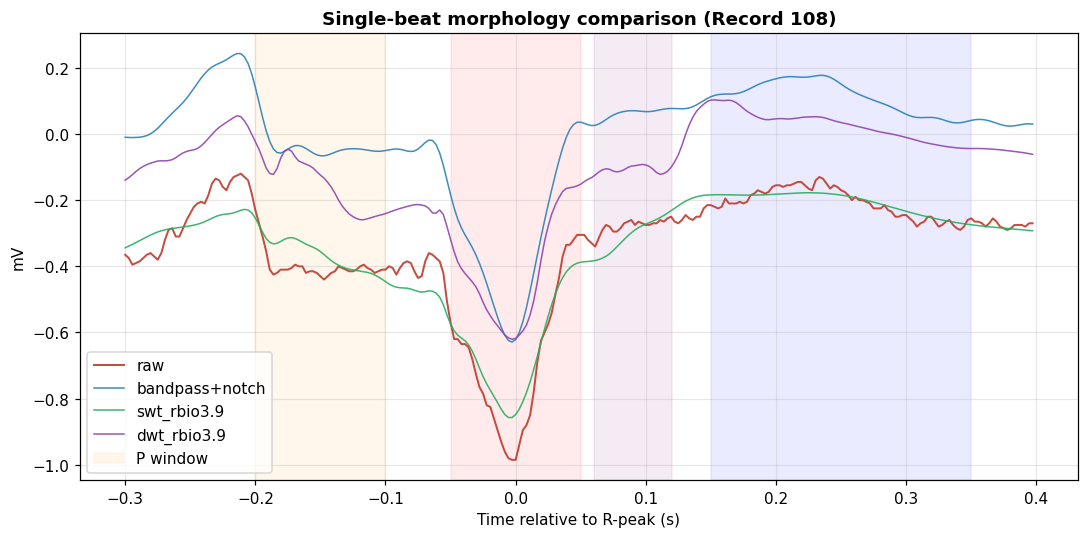

In [24]:
# Single-beat overlay -- reuses morph_variants & r_peaks, no recomputation
r = r_peaks[10]
i0, i1 = r - int(0.3 * fs_r108), r + int(0.4 * fs_r108)
t_beat = np.arange(i1 - i0) / fs_r108 - 0.3

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'raw': '#c0392b', 'bandpass+notch': '#2980b9', 'swt_rbio3.9': '#27ae60', 'dwt_rbio3.9': '#8e44ad'}
for name, sig in morph_variants.items():
    ax.plot(t_beat, sig[i0:i1], label=name, color=colors[name], linewidth=1.3 if name == 'raw' else 1.0, alpha=0.9)

ax.axvspan(-0.20, -0.10, alpha=0.08, color='orange', label='P window')
ax.axvspan(-0.05, 0.05, alpha=0.08, color='red')
ax.axvspan(0.06, 0.12, alpha=0.08, color='purple')
ax.axvspan(0.15, 0.35, alpha=0.08, color='blue')
ax.set_title('Single-beat morphology comparison (Record 108)', fontweight='bold')
ax.set_xlabel('Time relative to R-peak (s)'); ax.set_ylabel('mV')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
# Part 2 — Adaptive Time-Frequency Encoder (ATFE) + Reservoir Dynamics Branch: Direct Multi-Step Raw-ECG Forecasting (All 48 Records)



## 10. Algorithm (reference, updated for streaming)

```
Stage 1 - ATFE (per record, BEFORE the reservoir):
    x = cleaned[r]
    F_conv = MultiScaleConvBank(x, kernel_sizes={3,7,9})
    F_cwt  = MorletCWT(x, scales={2,4,8,16,32})
    Z[r]   = zscore(concat(F_conv, F_cwt))                 # R^{L x D}

Stage 2 - Reservoir setup (fixed, untrained):
    W_in in R^{Nr x D}, W_res in R^{Nr x Nr} sparse, rho(W_res) < 1

Stage 3 - STREAMING scan + windowing, fused into one O(L) pass per record
          (fixes the OOM: never materializes a (windows, lookback, D) tensor):
    state(0) = 0
    for t in 1..L:
        state(t) = (1-alpha) state(t-1) + alpha * tanh(W_in @ Z[t] + W_res @ state(t-1))
        if t >= lookback and (window index i = t-lookback) is on the stride grid:
            Phi_i = state(t)                      # (Nr,) -- NOT the (lookback,D) window
            Y_i   = x[t+1 : t+1+H]                 # per horizon H
    # only Phi (n_windows x Nr) and Y (n_windows x H) are ever stored

Stage 4 - MIMO ridge head (paper Eq. 2), closed form, no autoregression:
    W_out = (Phi_train^T Phi_train + beta I)^-1 Phi_train^T Y_train
    Y_hat = Phi_test @ W_out
```


## 11. Adaptive Time-Frequency Encoder (ATFE)

In [25]:
ATFE_SCALES = [2, 4, 8, 16, 32]          
ATFE_KERNEL_SIZES = (3, 7, 9)            
ATFE_FILTERS_PER_KERNEL = 2              
ATFE_RNG = np.random.default_rng(7)      

def morlet_cwt_features(x, scales=ATFE_SCALES):
    coeffs, _ = pywt.cwt(x, scales, 'morl')
    return coeffs.T.astype(np.float32)

def multiscale_conv_bank(x, kernel_sizes=ATFE_KERNEL_SIZES, n_filters=ATFE_FILTERS_PER_KERNEL, rng=ATFE_RNG):
    feats = []
    for k in kernel_sizes:
        for _ in range(n_filters):
            kernel = rng.normal(size=k).astype(np.float32)
            kernel /= (np.linalg.norm(kernel) + 1e-8)
            feats.append(np.convolve(x, kernel, mode='same'))
    return np.stack(feats, axis=1).astype(np.float32)

def atfe_encode(x, scales=ATFE_SCALES, kernel_sizes=ATFE_KERNEL_SIZES,
                 n_filters=ATFE_FILTERS_PER_KERNEL, rng=ATFE_RNG):

    F_conv = multiscale_conv_bank(x, kernel_sizes, n_filters, rng)
    F_cwt  = morlet_cwt_features(x, scales)
    Z = np.concatenate([F_conv, F_cwt], axis=1)
    mu, sd = Z.mean(axis=0, keepdims=True), Z.std(axis=0, keepdims=True)
    sd[sd < 1e-8] = 1e-8
    return (Z - mu) / sd


## 12. Precompute ATFE Features  Once per Record (Not per Window)

In [26]:
atfe_by_record = {}
t0 = time.time()
for rec_name in records:
    atfe_by_record[rec_name] = atfe_encode(cleaned[rec_name])
D_ATFE = atfe_by_record[records[0]].shape[1]
print(f"ATFE computed for {len(atfe_by_record)} records in {time.time() - t0:.1f}s "
      f"| feature dim D = {D_ATFE} ({len(ATFE_KERNEL_SIZES) * ATFE_FILTERS_PER_KERNEL} conv + {len(ATFE_SCALES)} CWT)")


ATFE computed for 48 records in 11.4s | feature dim D = 11 (6 conv + 5 CWT)


## 13. Train/Test Split  Intra-Patient, Chronological, Per Record


In [27]:
TRAIN_FRAC = 0.7

split_raw = {}
for rec_name in records:
    x_full = cleaned[rec_name]
    Z_full = atfe_by_record[rec_name]
    split_idx = int(len(x_full) * TRAIN_FRAC)
    split_raw[rec_name] = {
        'x_train': x_full[:split_idx], 'Z_train': Z_full[:split_idx],
        'x_test':  x_full[split_idx:], 'Z_test':  Z_full[split_idx:],
    }
print(f"Split {len(split_raw)} records at {TRAIN_FRAC:.0%} train / {1 - TRAIN_FRAC:.0%} test (chronological, per record)")


Split 48 records at 70% train / 30% test (chronological, per record)


## 14. Reservoir Setup  Driven by ATFE Features

Built *before* windowing now, since the streaming pass in Section 15 needs `W_in`/`W_res` to encode
states on the fly.

$$x(t) = (1-\alpha)\,x(t-1) + \alpha \tanh\big(W_{in}\, Z_{TF}(t) + W_{res}\, x(t-1)\big)$$

- $W_{in} \in \mathbb{R}^{N_r \times D}$, $W_{res} \in \mathbb{R}^{N_r \times N_r}$ fixed, random,
  sparsified (10% density), rescaled to spectral radius $\rho(W_{res}) < 1$.
- Only the linear readout $W_{out}$ is trained (Section 16, closed form).

In [28]:
RESERVOIR_SIZE = 200     # Nr
SPECTRAL_RADIUS = 0.90
LEAK_RATE = 0.30
INPUT_SCALE = 1.0
RIDGE_BETA = 1e-2
RESERVOIR_DENSITY = 0.10

rng = np.random.default_rng(42)

def make_reservoir(Nr, D, spectral_radius=SPECTRAL_RADIUS, input_scale=INPUT_SCALE,
                    density=RESERVOIR_DENSITY, rng=rng):
    W_in = rng.uniform(-input_scale, input_scale, size=(Nr, D)).astype(np.float32)
    W_res = rng.uniform(-1, 1, size=(Nr, Nr)).astype(np.float32)
    W_res *= (rng.random((Nr, Nr)) < density)
    eig = np.max(np.abs(np.linalg.eigvals(W_res)))
    if eig > 0:
        W_res *= spectral_radius / eig
    return W_in, W_res

W_in, W_res = make_reservoir(RESERVOIR_SIZE, D_ATFE)
print(f"Reservoir: Nr={RESERVOIR_SIZE}, D_in={D_ATFE}, "
      f"actual spectral radius={np.max(np.abs(np.linalg.eigvals(W_res))):.3f}")


Reservoir: Nr=200, D_in=11, actual spectral radius=0.900


## 15. Streaming Windowing + Reservoir Encoding (memory-safe, fixes the OOM)


In [29]:
LOOKBACK = 256          
TRAIN_STRIDE = 40      
TEST_STRIDE = 20        
HORIZONS = [64, 128]   

def stream_record(x, Z, lookback, horizons, stride, W_in, W_res, alpha=LEAK_RATE):

    L = len(x)
    Nr = W_in.shape[0]
    state = np.zeros(Nr, dtype=np.float32)
    out = {h: {'Phi': [], 'Y': []} for h in horizons}
    last_start = {h: L - lookback - h for h in horizons}
    for t in range(L):
        state = (1 - alpha) * state + alpha * np.tanh(W_in @ Z[t] + W_res @ state)
        if t < lookback - 1:
            continue
        i = t - lookback + 1                      
        for h in horizons:
            if i > last_start[h] or i % stride != 0:
                continue
            out[h]['Phi'].append(state.copy())
            out[h]['Y'].append(x[t + 1: t + 1 + h])
    return out

pooled = {h: {'Phi_tr': [], 'Y_tr': [], 'Phi_te': [], 'Y_te': [], 'recid_te': []} for h in HORIZONS}
t0 = time.time()
for rec_name, d in split_raw.items():
    tr = stream_record(d['x_train'], d['Z_train'], LOOKBACK, HORIZONS, TRAIN_STRIDE, W_in, W_res)
    te = stream_record(d['x_test'],  d['Z_test'],  LOOKBACK, HORIZONS, TEST_STRIDE,  W_in, W_res)
    for h in HORIZONS:
        pooled[h]['Phi_tr'].extend(tr[h]['Phi']); pooled[h]['Y_tr'].extend(tr[h]['Y'])
        pooled[h]['Phi_te'].extend(te[h]['Phi']); pooled[h]['Y_te'].extend(te[h]['Y'])
        pooled[h]['recid_te'].extend([rec_name] * len(te[h]['Phi']))
print(f"Streaming reservoir pass over {len(split_raw)} records done in {time.time() - t0:.1f}s")

windows_by_horizon = {}
for h in HORIZONS:
    windows_by_horizon[h] = {
        'Phi_tr': np.asarray(pooled[h]['Phi_tr'], dtype=np.float32),
        'Y_tr':   np.asarray(pooled[h]['Y_tr'],   dtype=np.float32),
        'Phi_te': np.asarray(pooled[h]['Phi_te'], dtype=np.float32),
        'Y_te':   np.asarray(pooled[h]['Y_te'],   dtype=np.float32),
        'recid_te': np.asarray(pooled[h]['recid_te']),
    }
    w = windows_by_horizon[h]
    print(f"H={h}: train windows={len(w['Phi_tr'])}, test windows={len(w['Phi_te'])}")
del pooled


Streaming reservoir pass over 48 records done in 364.0s
H=64: train windows=545664, test windows=467280
H=128: train windows=545568, test windows=467088


## 16. Training Closed-Form Ridge Readout per Horizon


In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_ridge_readout(Phi_train, Y_train, beta=RIDGE_BETA):
    """Closed-form solution: W_out = (Phi^T Phi + beta*I)^-1 Phi^T Y (paper Eq. 2, transposed form)."""
    Nr = Phi_train.shape[1]
    A = Phi_train.T @ Phi_train + beta * np.eye(Nr, dtype=Phi_train.dtype)
    B = Phi_train.T @ Y_train
    return np.linalg.solve(A, B)

results = {}
for h in HORIZONS:
    w = windows_by_horizon[h]
    t0 = time.time()
    W_out = train_ridge_readout(w['Phi_tr'], w['Y_tr'])
    preds = w['Phi_te'] @ W_out
    trues = w['Y_te']

    rmse = np.sqrt(mean_squared_error(trues, preds))
    mae = mean_absolute_error(trues, preds)
    r2 = r2_score(trues.reshape(-1), preds.reshape(-1))
    total_time = time.time() - t0

    results[h] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'total_time': total_time,
                  'preds': preds, 'trues': trues, 'rec_id_te': w['recid_te'], 'W_out': W_out}
    print(f"H={h}: RMSE={rmse:.4f} mV, MAE={mae:.4f} mV, R2={r2:.4f}, time={total_time:.1f}s")


H=64: RMSE=0.5145 mV, MAE=0.3929 mV, R2=-0.3126, time=1.0s
H=128: RMSE=0.5244 mV, MAE=0.4004 mV, R2=-0.3639, time=1.4s


## 17. Metrics Table (pooled across all 48 records)

In [32]:
import pandas as pd

print(f"{'Horizon':<10}{'RMSE (mV)':>12}{'MAE (mV)':>12}{'R Squared':>12}{'Compute Time (s)':>20}")
for h in HORIZONS:
    r = results[h]
    print(f"{h:<10}{r['rmse']:>12.4f}{r['mae']:>12.4f}{r['r2']:>12.4f}{r['total_time']:>20.3f}")

metrics_table = pd.DataFrame({
    'Horizon': HORIZONS,
    'RMSE (mV)': [results[h]['rmse'] for h in HORIZONS],
    'MAE (mV)': [results[h]['mae'] for h in HORIZONS],
    'R Squared': [results[h]['r2'] for h in HORIZONS],
    'Computational Time (s)': [results[h]['total_time'] for h in HORIZONS],
})
metrics_table


Horizon      RMSE (mV)    MAE (mV)   R Squared    Compute Time (s)
64              0.5145      0.3929     -0.3126               0.989
128             0.5244      0.4004     -0.3639               1.422


,Horizon,RMSE (mV),MAE (mV),R Squared,Computational Time (s)
0,64,0.514456,0.392901,-0.312578,0.988675
1,128,0.524408,0.400432,-0.363888,1.421678


## 18. Insights & Visualizations

### 18a. Actual vs. Predicted raw ECG across the horizon


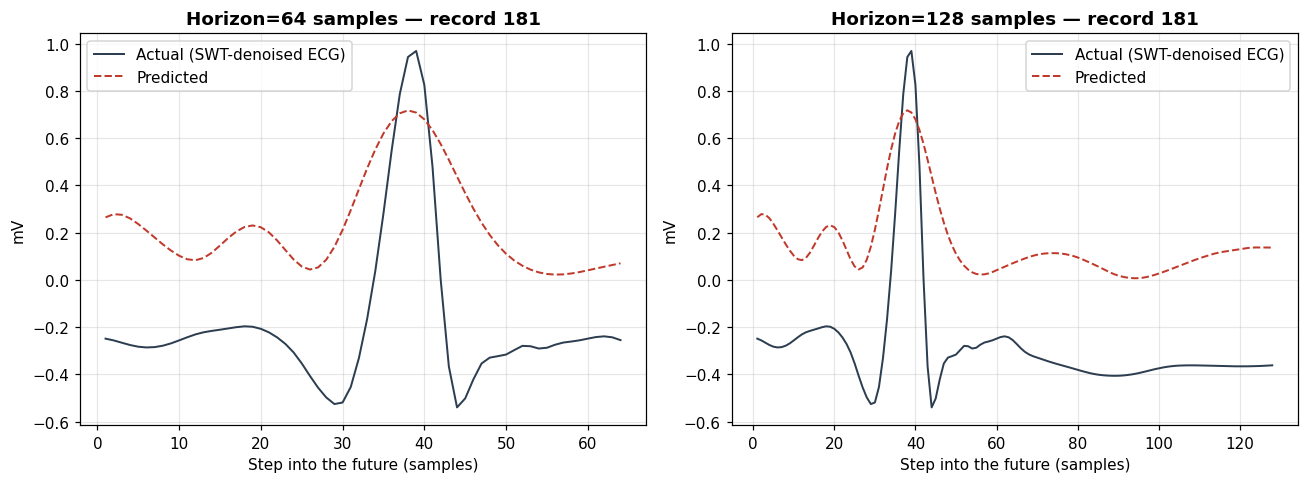

In [38]:
EXAMPLE_RECORD = '181'

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(6 * len(HORIZONS), 4.5))
if len(HORIZONS) == 1:
    axes = [axes]
for ax, h in zip(axes, HORIZONS):
    r = results[h]
    idx_candidates = np.where(r['rec_id_te'] == EXAMPLE_RECORD)[0]
    example_idx = idx_candidates[0] if len(idx_candidates) else 0

    actual = r['trues'][example_idx]
    pred = r['preds'][example_idx]
    steps = np.arange(1, h + 1)
    ax.plot(steps, actual, '-', color='#2c3e50', label='Actual (SWT-denoised ECG)', linewidth=1.3)
    ax.plot(steps, pred, '--', color='#c0392b', label='Predicted', linewidth=1.3)
    ax.set_title(f'Horizon={h} samples — record {EXAMPLE_RECORD}', fontweight='bold')
    ax.set_xlabel('Step into the future (samples)'); ax.set_ylabel('mV')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 18b. RMSE across all points in the horizon, averaged over all test samples (all 48 records)

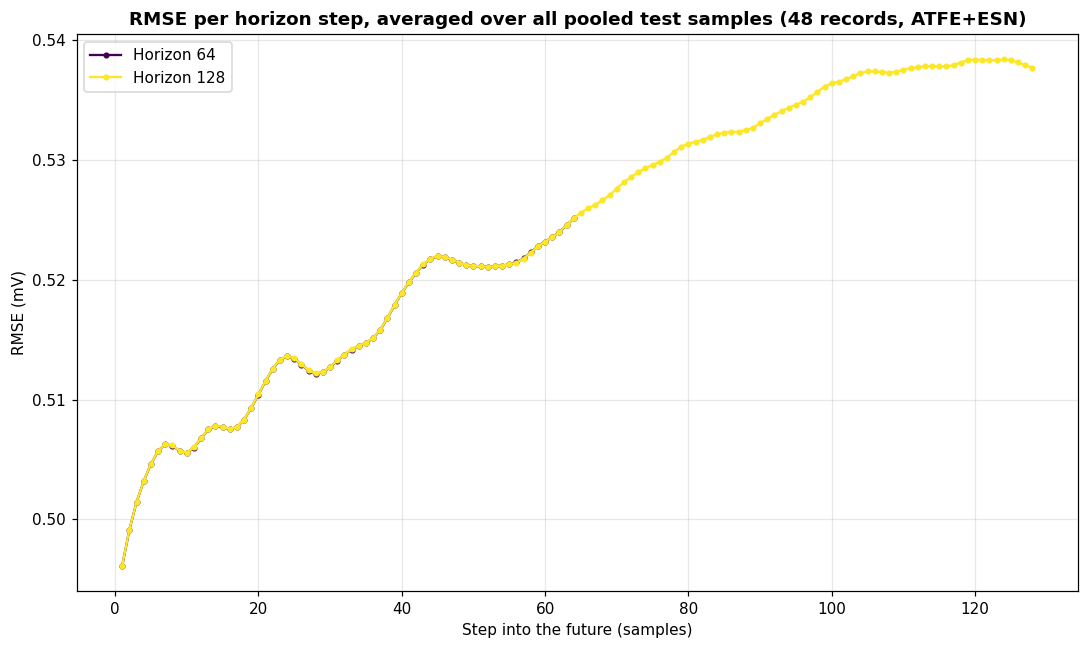

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(HORIZONS)))

for h, c in zip(HORIZONS, colors):
    r = results[h]
    per_step_rmse = np.sqrt(np.mean((r['trues'] - r['preds']) ** 2, axis=0))
    ax.plot(np.arange(1, h + 1), per_step_rmse, 'o-', color=c, label=f'Horizon {h}',
            linewidth=1.5, markersize=3)

ax.set_title('RMSE per horizon step, averaged over all pooled test samples (48 records, ATFE+ESN)', fontweight='bold')
ax.set_xlabel('Step into the future (samples)'); ax.set_ylabel('RMSE (mV)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 18c. Per-record RMSE breakdown — where the model fails by patient

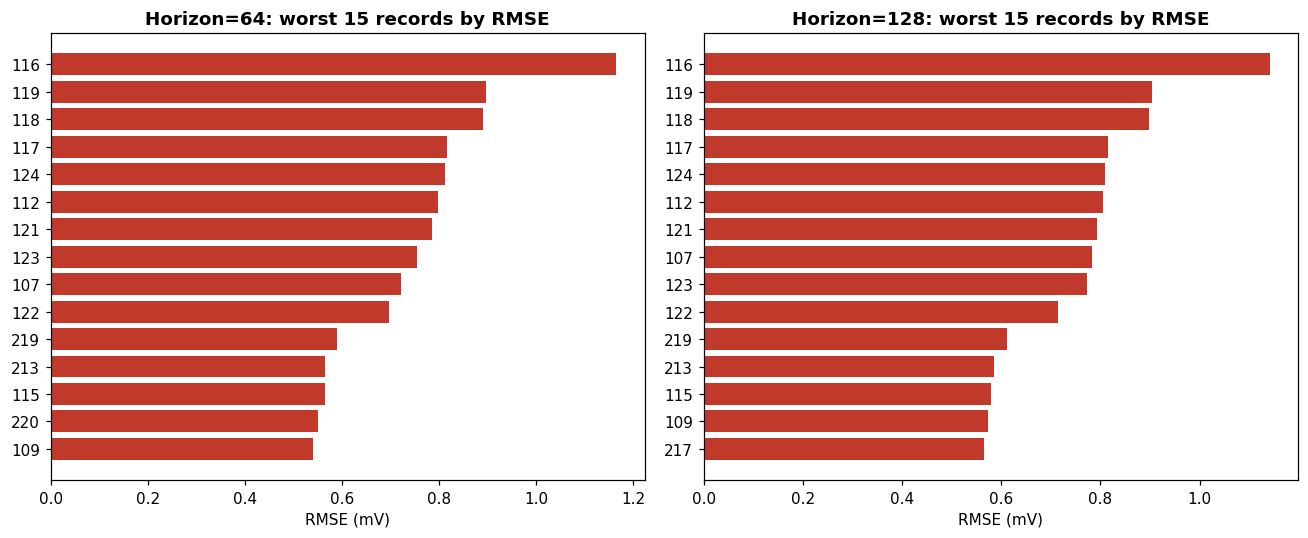

In [35]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(6 * len(HORIZONS), 5))
if len(HORIZONS) == 1:
    axes = [axes]

worst_records = {}
for ax, h in zip(axes, HORIZONS):
    r = results[h]
    per_win_sq_err = np.mean((r['trues'] - r['preds']) ** 2, axis=1)
    df = pd.DataFrame({'record': r['rec_id_te'], 'sq_err': per_win_sq_err})
    rmse_by_record = df.groupby('record')['sq_err'].mean().apply(np.sqrt).sort_values(ascending=False)
    worst_records[h] = rmse_by_record

    top15 = rmse_by_record.head(15)
    ax.barh(top15.index[::-1], top15.values[::-1], color='#c0392b')
    ax.set_title(f'Horizon={h}: worst 15 records by RMSE', fontweight='bold')
    ax.set_xlabel('RMSE (mV)')
plt.tight_layout(); plt.show()
